In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from utils import draw_epipolar, visualize_pcd

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# 1

In [2]:
pts_3d = np.loadtxt("./data/pts3d-norm.txt")  # [X, Y, Z, 1]
pts_2d = np.loadtxt("./data/pts2d-norm-pic.txt")  # [u, v, 1]

# Append 1s to 3D points for homogeneous coordinates
pts_3d_homogeneous = np.hstack((pts_3d, np.ones((pts_3d.shape[0], 1))))

# Compute Projection Matrix P
A = []
for i in range(pts_3d.shape[0]):
    X, Y, Z, W = pts_3d_homogeneous[i]
    u, v = pts_2d[i]
    A.append([X, Y, Z, W, 0, 0, 0, 0, -u*X, -u*Y, -u*Z, -u*W])
    A.append([0, 0, 0, 0, X, Y, Z, W, -v*X, -v*Y, -v*Z, -v*W])
A = np.array(A)

# Solve A * p = 0 using SVD
U, S, Vt = np.linalg.svd(A)
P = Vt[-1].reshape(3, 4)  # Last row of Vt

print("Projection Matrix P:\n", P)

# Verify Projection Matrix
projected_points = (P @ pts_3d_homogeneous.T).T
projected_points /= projected_points[:, 2:3]  # Normalize by the last coordinate

print("\nFirst few projected 2D points:", projected_points[:5, :2])
print("First few actual 2D points:", pts_2d[:5])

Projection Matrix P:
 [[ 0.45827554 -0.29474237 -0.01395746  0.0040258 ]
 [-0.05085589 -0.0545847  -0.54105993 -0.05237592]
 [ 0.10900958  0.17834548 -0.04426782  0.5968205 ]]

First few projected 2D points: [[ 1.04675229 -0.36260293]
 [-1.68404882 -0.39789506]
 [-0.94477667 -0.42048269]
 [ 1.06696778  0.06863591]
 [ 0.60831667 -0.07645742]]
First few actual 2D points: [[ 1.0486 -0.3645]
 [-1.6851 -0.4004]
 [-0.9437 -0.42  ]
 [ 1.0682  0.0699]
 [ 0.6077 -0.0771]]


Projection Matrix P:
 [[ 0.45827554 -0.29474237 -0.01395746  0.0040258 ]
 [-0.05085589 -0.0545847  -0.54105993 -0.05237592]
 [ 0.10900958  0.17834548 -0.04426782  0.5968205 ]]


# 2

In [3]:
data = np.load("./data/temple.npz")

pts1 = data["pts1"]
pts2 = data["pts2"]
img1 = cv2.imread("./data/im1.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("./data/im2.png", cv2.IMREAD_GRAYSCALE)

# Normalize points
T1 = np.eye(3)
T1[0, 0] = T1[1, 1] = 1 / max(img1.shape)
T2 = np.eye(3)
T2[0, 0] = T2[1, 1] = 1 / max(img2.shape)

pts1_normalized = (T1 @ np.hstack((pts1, np.ones((pts1.shape[0], 1)))).T).T
pts2_normalized = (T2 @ np.hstack((pts2, np.ones((pts2.shape[0], 1)))).T).T

In [4]:
# Build A matrix for Eight-Point Algorithm
A = np.zeros((pts1.shape[0], 9))
for i in range(pts1.shape[0]):
    u1, v1 = pts1_normalized[i, :2]
    u2, v2 = pts2_normalized[i, :2]
    A[i] = [u1*u2, u1*v2, u1, v1*u2, v1*v2, v1, u2, v2, 1]

# Solve A*f=0 using SVD
U, S, Vt = np.linalg.svd(A)
F_normalized = Vt[-1].reshape(3, 3)

# Enforce rank-2 constraint
U, S, Vt = np.linalg.svd(F_normalized)
S[2] = 0
F_normalized = U @ np.diag(S) @ Vt

# Denormalize F
F = T2.T @ F_normalized @ T1
F /= F[2, 2]  # Normalize

print("\nFundamental Matrix F:\n", F)




Fundamental Matrix F:
 [[-8.55629053e-07  3.14052683e-05 -7.31606892e-03]
 [ 1.42140129e-05  3.14691357e-07  2.59284111e-01]
 [ 3.96151277e-03 -2.69985755e-01  1.00000000e+00]]


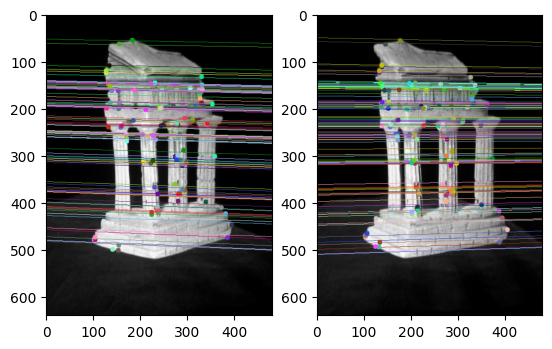

In [5]:
# Draw epipolar lines
draw_epipolar(img1, img2, F, pts1, pts2)



# 3

### 1 & 2

In [6]:

K1 = data["K1"]
K2 = data["K2"]



In [7]:
# Compute Fundamental Matrix using OpenCV
F_cv, _ = cv2.findFundamentalMat(pts1, pts2, method=cv2.FM_8POINT)
print("\nFundamental Matrix from cv2.findFundamentalMat:\n", F_cv)

# Essential matrix
E = K2.T @ F_cv @ K1
print("\nEssential Matrix E:\n", E)


Fundamental Matrix from cv2.findFundamentalMat:
 [[-4.56467394e-07  2.43227032e-05  1.66715104e-04]
 [ 1.54501891e-05  5.64438707e-07 -2.35086559e-01]
 [-4.19950968e-03  2.25685941e-01  1.00000000e+00]]

Essential Matrix E:
 [[  -1.0551774    56.42814506    9.17409425]
 [  35.84410427    1.31422261 -351.3790752 ]
 [  -0.79493824  355.80639208    0.42113092]]


### 3

In [8]:
# Decompose E to find R and t
R1, R2, t = cv2.decomposeEssentialMat(E)

In [9]:
t

array([[ 0.98731854],
       [ 0.02558995],
       [-0.15667561]])

In [10]:
# Choose correct R, t by checking positive depth
P1 = K1 @ np.hstack((np.eye(3), np.zeros((3, 1))))

In [11]:
best_t = None
best_R = None
best_points = None

for R in [R1, R2]:
    for t_vec in [t, -t]:
        P2 = K2 @ np.hstack((R, t_vec.reshape(-1, 1)))
        points_4d_hom = cv2.triangulatePoints(P1, P2, pts1.T, pts2.T)
        points_4d_hom = points_4d_hom[:, points_4d_hom[3] != 0]  # Avoid division by zero
        points_4d = (points_4d_hom / points_4d_hom[3])[:3].T

        # Check if most points have positive depth
        positive_depth_count = np.sum(points_4d[:, 2] > 0)
        print(f"R: {R}, t: {t_vec}, Positive Depth Count: {positive_depth_count}")

        if positive_depth_count > len(points_4d) / 2:
            best_R = R
            best_t = t_vec
            best_points = points_4d

# Verify if a valid R and t were found
if best_R is None or best_t is None:
    raise ValueError("No valid R and t found. Please check input data and matches.")


R: [[ 9.66378185e-01 -2.39125056e-02  2.56010539e-01]
 [ 2.29039549e-02  9.99713715e-01  6.92072058e-03]
 [-2.56102739e-01 -8.24379544e-04  9.66649216e-01]], t: [[ 0.98731854]
 [ 0.02558995]
 [-0.15667561]], Positive Depth Count: 20
R: [[ 9.66378185e-01 -2.39125056e-02  2.56010539e-01]
 [ 2.29039549e-02  9.99713715e-01  6.92072058e-03]
 [-2.56102739e-01 -8.24379544e-04  9.66649216e-01]], t: [[-0.98731854]
 [-0.02558995]
 [ 0.15667561]], Positive Depth Count: 20
R: [[ 9.98058454e-01  2.80642244e-02 -5.56032501e-02]
 [ 2.80115603e-02 -9.99606108e-01 -1.72643730e-03]
 [-5.56297995e-02  1.65551547e-04 -9.98451450e-01]], t: [[ 0.98731854]
 [ 0.02558995]
 [-0.15667561]], Positive Depth Count: 4
R: [[ 9.98058454e-01  2.80642244e-02 -5.56032501e-02]
 [ 2.80115603e-02 -9.99606108e-01 -1.72643730e-03]
 [-5.56297995e-02  1.65551547e-04 -9.98451450e-01]], t: [[-0.98731854]
 [-0.02558995]
 [ 0.15667561]], Positive Depth Count: 4


In [13]:
print("\nBest Rotation Matrix R:\n", best_R)


Best Rotation Matrix R:
 [[ 9.66378185e-01 -2.39125056e-02  2.56010539e-01]
 [ 2.29039549e-02  9.99713715e-01  6.92072058e-03]
 [-2.56102739e-01 -8.24379544e-04  9.66649216e-01]]


In [14]:
print("Best Translation Vector t:\n", best_t)

Best Translation Vector t:
 [[-0.98731854]
 [-0.02558995]
 [ 0.15667561]]


In [15]:
print("\nTriangulated 3D points:", best_points[:5])


Triangulated 3D points: [[ 4.2869596   4.2869596   0.87407041]
 [-0.99546709 -0.99546709 -0.9952166 ]
 [ 4.2869596   4.2869596   0.87407041]
 [-0.99546709 -0.99546709 -0.9952166 ]
 [ 4.2869596   4.2869596   0.87407041]]


### 4

In [12]:
P2 = K2 @ np.hstack((best_R, best_t.reshape(-1, 1)))
print("\nProjection Matrix P1:\n", P1)
print("Projection Matrix P2:\n", P2)


Projection Matrix P1:
 [[1.5204e+03 0.0000e+00 3.0230e+02 0.0000e+00]
 [0.0000e+00 1.5259e+03 2.4690e+02 0.0000e+00]
 [0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00]]
Projection Matrix P2:
 [[ 1.39186153e+03 -3.66057834e+01  6.81456482e+02 -1.45375608e+03]
 [-2.82826215e+01  1.52525962e+03  2.49226019e+02 -3.64493323e-01]
 [-2.56102739e-01 -8.24379544e-04  9.66649216e-01  1.56675614e-01]]


### 5

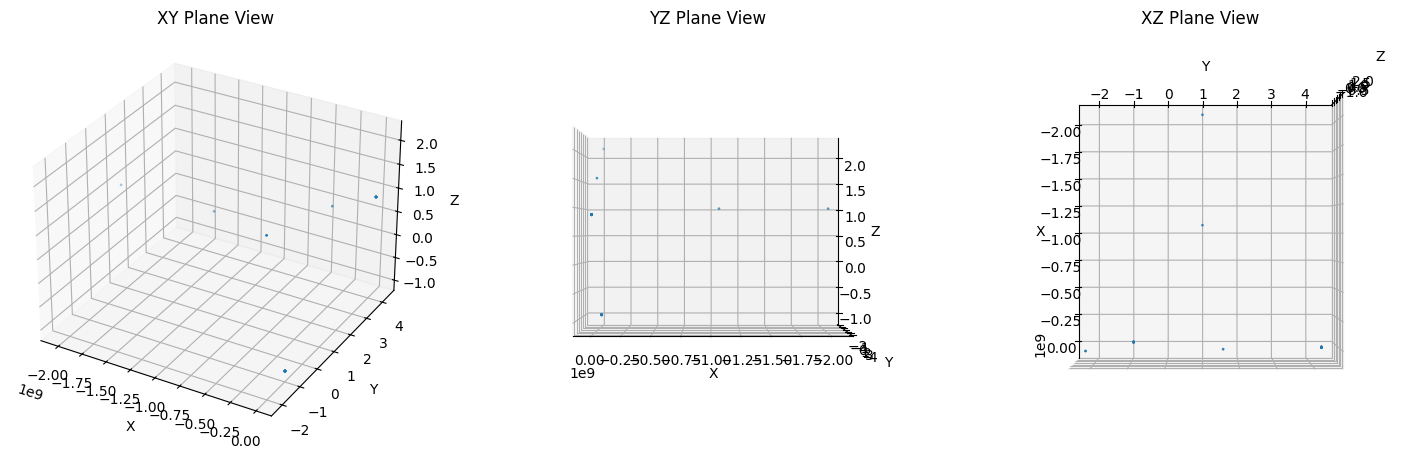

In [16]:
def visualize_from_3_views(points_3d):
    """Visualize the point cloud from 3 different views."""
    fig = plt.figure(figsize=(18, 6))

    # View 1: XY Plane
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=1)
    ax1.set_title("XY Plane View")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")

    # View 2: YZ Plane
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=1)
    ax2.view_init(elev=0, azim=90)  # Rotate to view YZ
    ax2.set_title("YZ Plane View")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")

    # View 3: XZ Plane
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=1)
    ax3.view_init(elev=90, azim=0)  # Rotate to view XZ
    ax3.set_title("XZ Plane View")
    ax3.set_xlabel("X")
    ax3.set_ylabel("Y")
    ax3.set_zlabel("Z")

    plt.show()

# Visualize the triangulated points from 3 views
visualize_from_3_views(best_points)

### 6

In [17]:

def save_point_cloud_to_file(points_3d, filename="point_cloud.xyz"):
    """Save the 3D points to a file in .xyz format."""
    np.savetxt(filename, points_3d, fmt="%.6f", header="X Y Z", comments="")
    print(f"Point cloud saved to {filename}")

# Save the triangulated points to a file
save_point_cloud_to_file(best_points)

Point cloud saved to point_cloud.xyz


In [1]:
# Visualize point cloud
visualize_pcd(best_points)

NameError: name 'visualize_pcd' is not defined